# 🏁 Análise Unificada Multi-Piloto — Delta Time & Evolução por Stint

Este notebook consolida **todos** os pilotos e stints registrados em `datasets.py` (2 pistas: Charlotte Roval 2025 e Summit Point) para gerar:

1. Delta time — **Experiente vs Intermediário**
2. Delta time — **Amadores vs Intermediário** (subplots)
3. Evolução do tempo de volta ao longo dos stints
4. Tabela-resumo pronta para atualizar a **Tabela 5** do artigo

> ⚠️ **Nota sobre papéis dos pilotos**: há divergência entre `driver_alias.py` (Rodrigo=A, Tomaz=B, Morsinaldo=C) e classificações anteriores do artigo. Este notebook usa a classificação mais recente informada por Tomaz:
> - **Rodrigo** → Experiente
> - **Tomaz** → Intermediário (referência das comparações com amadores)
> - **Morsinaldo** → Amador original
> - **Thallys, Igor, Hilton** → Amadores novos
>
> Revise `ROLE_MAP` abaixo antes de gerar as figuras finais para o artigo.


## 1. Setup e imports

In [1]:
import sys
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from config import (
    DATASETS, DRIVER_ALIAS, resolve_stint_files, load_stint,
    basic_clean_and_units, build_lap_validity_table, TRACK_CONFIGS,
)

print(f"Pistas no dataset : {list(DATASETS.keys())}")
for track_id, cfg in DATASETS.items():
    drivers = list(cfg["sessions"].keys())
    print(f"  {track_id}: pilotos = {drivers}")


Pistas no dataset : ['charlotte_roval_2025', 'summit_point']
  charlotte_roval_2025: pilotos = ['Tomaz', 'Morsinaldo', 'Rodrigo', 'Thallys', 'Igor', 'Hilton']
  summit_point: pilotos = ['Tomaz', 'Morsinaldo', 'Rodrigo', 'Thallys', 'Igor', 'Hilton']


In [2]:
# --- Papéis dos pilotos (Roles) em Inglês ---
ROLE_MAP = {
    "Rodrigo":    "Driver A",
    "Tomaz":      "Driver B",
    "Morsinaldo": "Driver C",
    "Thallys":    "Driver D",
    "Igor":       "Driver E",
    "Hilton":     "Driver F",
}

REFERENCE_INTERMEDIATE = "Tomaz"
REFERENCE_EXPERT       = "Rodrigo"
AMATEURS               = ["Morsinaldo", "Thallys", "Igor", "Hilton"]

ROLE_COLORS = {
    "Expert":              "#1f77b4",
    "Intermediate":        "#2ca02c",
    "Beginner (original)": "#ff7f0e",
    "Beginner (new)":      "#d62728",
}

OUT_DIR = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all" / "Iracing" / "img" / "unified_analysis"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR}")

Output directory: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis


## 2. Carregamento de todos os lap times (todas as pistas, pilotos e stints)

Percorre `DATASETS` dinamicamente — se você adicionar um piloto ou stint novo no `datasets.py`, este bloco já processa automaticamente.

Esta tabela (`master_laps`) é a **fonte única de verdade** sobre qual (piloto, pista, stint, volta) é a mais rápida — as seções seguintes reutilizam esses números em vez de recalcular concatenando telemetria de múltiplos stints (o que arriscaria colidir números de volta entre stints diferentes).

In [3]:
def build_master_laptime_table(datasets=DATASETS, role_map=ROLE_MAP, verbose=True):
    """Varre todas as pistas/pilotos/stints e monta uma tabela única de lap times."""
    rows = []
    for track_id, cfg in datasets.items():
        sessions = cfg["sessions"]
        for driver, stints in sessions.items():
            for stint_name in stints.keys():
                try:
                    files = [str(p) for p in resolve_stint_files(track_id, driver, stint_name)]
                    raw = load_stint(files)
                    df = basic_clean_and_units(raw)
                    lap_df = build_lap_validity_table(df)

                    lap_df = lap_df.copy()
                    lap_df["Track"]  = track_id
                    lap_df["Driver"] = driver
                    lap_df["Role"]   = role_map.get(driver, "Desconhecido")
                    lap_df["Stint"]  = stint_name

                    rows.append(lap_df)
                    if verbose:
                        n_valid = int(lap_df["Valid"].sum())
                        print(f"OK {track_id:22s} | {driver:11s} | {stint_name:10s} | {n_valid} voltas validas")
                except Exception as e:
                    print(f"FALHA em {track_id}/{driver}/{stint_name}: {e}")

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


In [4]:
# --- Execução (usa cache em pickle para reprocessamentos futuros) ---
CACHE_PATH = OUT_DIR / "master_laps_cache.pkl"
FORCE_RELOAD = True  # mude para True para reprocessar tudo do zero

if CACHE_PATH.exists() and not FORCE_RELOAD:
    master_laps = pd.read_pickle(CACHE_PATH)
    print(f"Cache carregado: {len(master_laps)} linhas")
else:
    master_laps = build_master_laptime_table()
    master_laps.to_pickle(CACHE_PATH)
    print(f"Processado do zero e salvo em cache: {len(master_laps)} linhas")

master_laps.head()


    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-22-34(Tomaz-warmup).ibt … OK (19,341 samples, laps 0–3)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (4 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 2 laps
  🏆 Fastest : Lap 1  (01:38.767)
  ❌ Invalid : 2 laps
     Lap   0  05:20.450  → LapTime=320.4s | GPS=95.0%<100%
     Lap   3  00:07.367  → CompletedPct=0.065<0.995 | FracLowSpeed=0.44 | LapTime=7.4s | GPS=4.0%<100%
──────────────────────────────────────────────────────────────
OK charlotte_roval_2025   | Tomaz       | warmup     | 2 voltas validas
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-30-08(Tomaz-stint1).ibt … OK (20,065 samples, laps 0–3)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (4 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 2 laps
  🏆 Fastest : Lap 1  (01:36.4

,Lap,LapTime_s,StartPct,CompletedPct,FracLowSpeed,MaxSpeed_kph,GpsCoverage_Pct,Valid,InvalidReason,Track,Driver,Role,Stint
0,0,320.450000,0.000000,0.999965,0.074858,186.816660,0.95,False,LapTime=320.4s | GPS=95.0%<100%,charlotte_roval_2025,Tomaz,Driver B,warmup
1,1,98.766667,0.000087,0.999852,0.000000,186.785156,1.00,True,OK,charlotte_roval_2025,Tomaz,Driver B,warmup
2,2,110.650000,0.000013,0.999908,0.021238,186.157219,1.00,True,OK,charlotte_roval_2025,Tomaz,Driver B,warmup
3,3,7.366667,0.000065,0.065122,0.436652,127.857788,0.04,False,CompletedPct=0.065<0.995 | FracLowSpeed=0.44 |...,charlotte_roval_2025,Tomaz,Driver B,warmup
4,0,332.200000,0.000000,0.999871,0.064604,180.899615,0.95,False,LapTime=332.2s | GPS=95.0%<100%,charlotte_roval_2025,Tomaz,Driver B,stint_1


## 3. Delta Time — Experiente vs Intermediário

In [5]:
def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> dict:
    """Alinha uma volta por LapDistPct em um grid comum."""
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}

    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}

    def interp(y):
        return np.interp(grid, x, y)

    return {
        "LapDistPct": grid,
        "t_rel": interp(t_rel.to_numpy()),
        "speed": interp(g["Speed_KPH"].to_numpy()),
    }


def get_best_stint_and_lap(track_id: str, driver: str, master_laps: pd.DataFrame, target_stint: str = None):
    """Consulta master_laps pela melhor volta válida. Opcionalmente filtra por um stint específico."""
    valid = master_laps[
        (master_laps["Track"] == track_id)
        & (master_laps["Driver"] == driver)
        & (master_laps["Valid"])
    ]
    
    # Se um stint específico for solicitado (ex: 'stint_1'), aplicamos o filtro
    if target_stint:
        valid = valid[valid["Stint"] == target_stint]

    if valid.empty:
        raise RuntimeError(f"No valid lap for {driver} at {track_id} (Stint: {target_stint})")
        
    best_row = valid.sort_values("LapTime_s").iloc[0]
    return str(best_row["Stint"]), int(best_row["Lap"]), float(best_row["LapTime_s"])


def load_stint_telemetry(track_id: str, driver: str, stint_name: str) -> pd.DataFrame:
    files = [str(p) for p in resolve_stint_files(track_id, driver, stint_name)]
    raw = load_stint(files)
    return basic_clean_and_units(raw)


def plot_delta_time(track_id: str, driver_ref: str, driver_test: str, master_laps: pd.DataFrame,
                     ax=None, grid_len: int = 2000, title_suffix: str = "", 
                     target_stint_ref: str = None, target_stint_test: str = None):
    """
    Plota o delta de tempo (test - ref), usando a MELHOR volta válida de cada piloto.
    Permite definir stints diferentes para o piloto de referência e o piloto em teste.
    """
    
    # Buscamos a volta de referência fixada no stint desejado (ex: stint_1)
    stint_ref, lap_ref, t_ref = get_best_stint_and_lap(track_id, driver_ref, master_laps, target_stint_ref)
    # Buscamos a volta do piloto em teste no seu stint atual de análise (ex: stint_5)
    stint_test, lap_test, t_test = get_best_stint_and_lap(track_id, driver_test, master_laps, target_stint_test)

    df_ref = load_stint_telemetry(track_id, driver_ref, stint_ref)
    df_test = load_stint_telemetry(track_id, driver_test, stint_test)

    grid = np.linspace(0.0, 1.0, grid_len)
    g_ref = df_ref[df_ref["Lap"] == lap_ref]
    g_test = df_test[df_test["Lap"] == lap_test]

    interp_ref = align_lap_by_dist(g_ref, grid)
    interp_test = align_lap_by_dist(g_test, grid)

    time_loss = interp_test["t_rel"] - interp_ref["t_rel"]
    final_delta = time_loss[-1]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(grid * 100.0, time_loss, color="firebrick", linewidth=2.2, label="Time Delta")
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.3)

    alias_ref = DRIVER_ALIAS.get(driver_ref, f"Driver {driver_ref}")
    alias_test = DRIVER_ALIAS.get(driver_test, f"Driver {driver_test}")

    # Atualizando o texto informativo para mostrar claramente os stints comparados
    info_text = (
        f"REF ({alias_ref}, Stint {stint_ref.split('_')[-1]}): {t_ref:.3f}s\n"
        f"TEST ({alias_test}, Stint {stint_test.split('_')[-1]}): {t_test:.3f}s\n"
        f"DIFF: {final_delta:+.3f}s"
    )
    
    ax.text(0.02, 0.97, info_text, transform=ax.transAxes, fontsize=8,
            va="top", family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor="gray"))

    ax.set_xlabel("Lap progress (%)")
    ax.set_ylabel("Time delta (s)")
    
    #ax.set_title(f"{alias_test} vs {alias_ref}{title_suffix}", fontsize=11, fontweight="bold")
    ax.legend(loc="upper right")

    if standalone:
        plt.tight_layout()
        fname = f"delta_{track_id}_{alias_test}_vs_{alias_ref}_{target_stint_test}.pdf"
        plt.savefig(OUT_DIR / fname, format='pdf', dpi=300, bbox_inches="tight")
        print(f"Saved: {OUT_DIR / fname}")
        plt.show()

    return final_delta


=== Charlotte Roval 2025 ===
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 18-30-08(Tomaz-stint1).ibt … OK (20,065 samples, laps 0–3)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\delta_charlotte_roval_2025_Driver B_vs_Driver A_stint_1.pdf


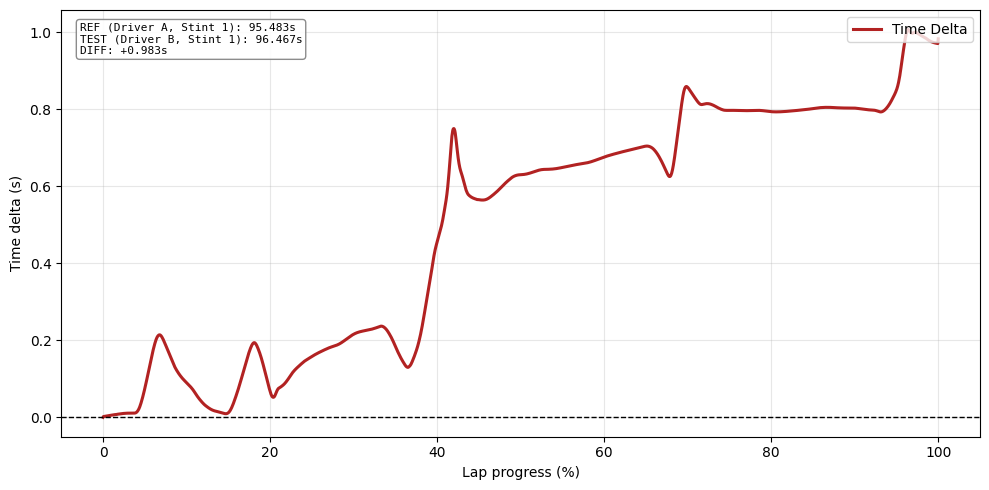


=== Summit Point - Main Circuit ===
    [1/2] Loading toyotagr86_summit summit raceway 2026-03-01 22-00-14(Rodrigo).ibt … OK (46,538 samples, laps 0–32)
    [2/2] Loading toyotagr86_summit summit raceway 2026-03-01 21-47-29(Rodrigo).ibt … OK (44,508 samples, laps 33–52)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-16 17-32-50(Tomaz-stint1).ibt … OK (31,726 samples, laps 0–7)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\delta_summit_point_Driver B_vs_Driver A_stint_1.pdf


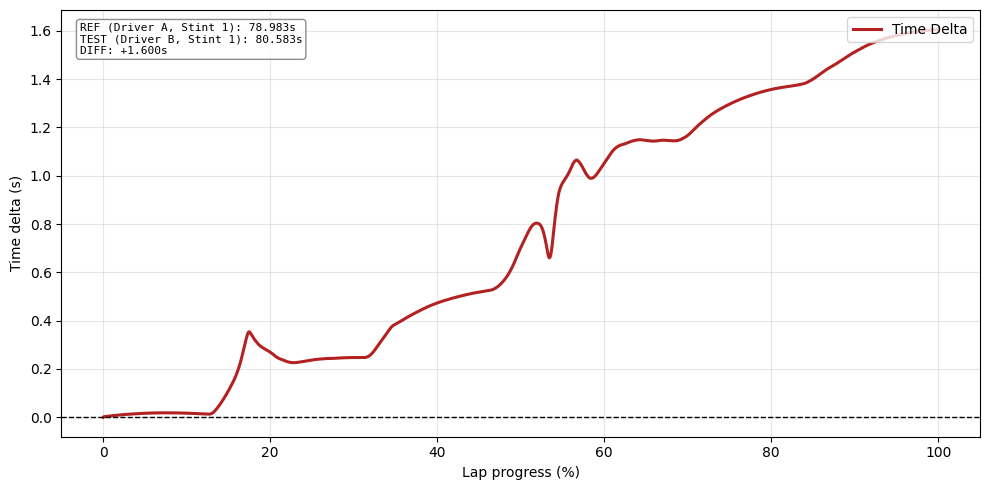

In [6]:
# --- Execução: Experiente vs Intermediário, para cada pista disponível ---
for track_id in DATASETS.keys():
    track_name = TRACK_CONFIGS[track_id]["track_name"]
    print(f"\n=== {track_name} ===")
    plot_delta_time(track_id, driver_ref=REFERENCE_EXPERT, driver_test=REFERENCE_INTERMEDIATE,
                     master_laps=master_laps, title_suffix=f" — {track_name}", target_stint_test='stint_1')



=== Charlotte Roval 2025 ===
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-02-08 15-06-22(Rodrigo).ibt … OK (274,948 samples, laps 0–49)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-20 19-27-49(Tomaz-stint5).ibt … OK (18,411 samples, laps 0–3)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\delta_charlotte_roval_2025_Driver B_vs_Driver A_stint_5.pdf


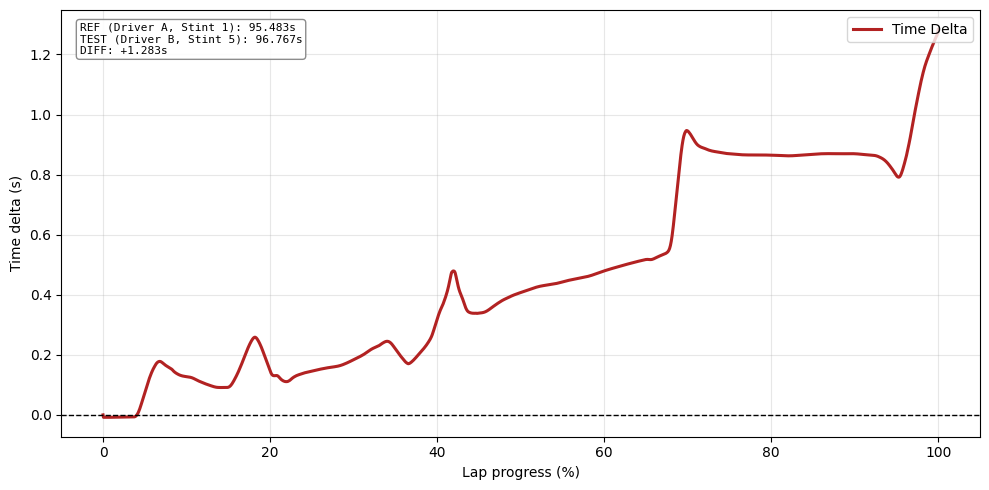


=== Summit Point - Main Circuit ===
    [1/2] Loading toyotagr86_summit summit raceway 2026-03-01 22-00-14(Rodrigo).ibt … OK (46,538 samples, laps 0–32)
    [2/2] Loading toyotagr86_summit summit raceway 2026-03-01 21-47-29(Rodrigo).ibt … OK (44,508 samples, laps 33–52)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-16 18-39-20(Tomaz-stint5).ibt … OK (21,294 samples, laps 0–5)
Saved: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\delta_summit_point_Driver B_vs_Driver A_stint_5.pdf


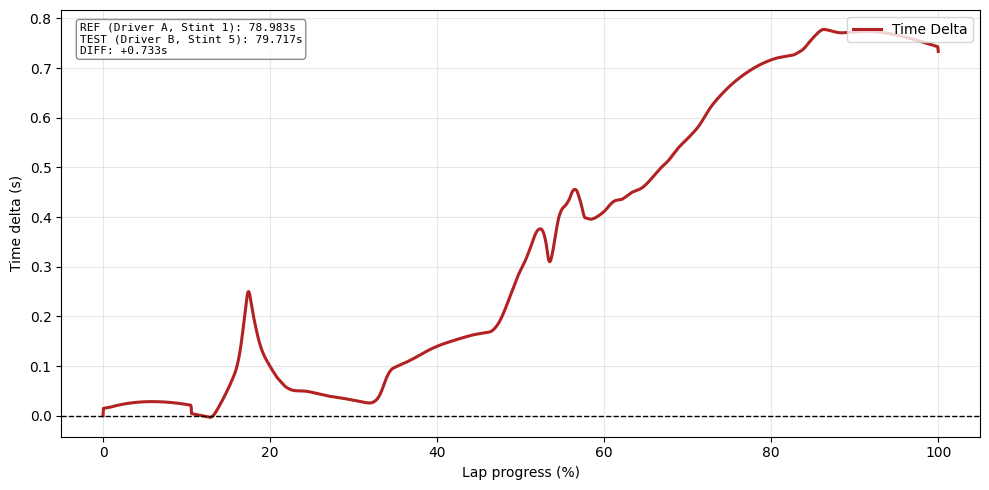

In [18]:
# --- Execução: Experiente vs Intermediário, para cada pista disponível ---
for track_id in DATASETS.keys():
    track_name = TRACK_CONFIGS[track_id]["track_name"]
    print(f"\n=== {track_name} ===")
    plot_delta_time(track_id, driver_ref=REFERENCE_EXPERT, driver_test=REFERENCE_INTERMEDIATE,
                     master_laps=master_laps, title_suffix=f" — {track_name}", target_stint_test='stint_5')

## 4. Delta Time — Amadores vs Intermediário (subplots)

In [7]:
def plot_amateur_grid(track_id: str, master_laps: pd.DataFrame, amateurs=AMATEURS, 
                      reference=REFERENCE_INTERMEDIATE, 
                      target_stint_ref="stint_1", target_stint_test="stint_1"):
    """
    Gera matriz de gráficos unificando o eixo Y e focando na comparação 
    entre o stint de referência e o stint de teste.
    """
    n = len(amateurs)
    ncols = 2
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    deltas = {}
    valid_axes = [] 
    
    for i, driver in enumerate(amateurs):
        ax = axes_flat[i]
        alias_driver = DRIVER_ALIAS.get(driver, f"Driver {driver}")
        
        try:
            # Chama a função passando os stints separados
            final_delta = plot_delta_time(track_id, driver_ref=reference, driver_test=driver,
                                           master_laps=master_laps, ax=ax, 
                                           target_stint_ref=target_stint_ref,
                                           target_stint_test=target_stint_test)
            deltas[driver] = final_delta
            valid_axes.append(ax) 
        except Exception as e:
            ax.set_title(f"{alias_driver}: error ({e})", fontsize=9, color="red")

    # Escala de Y uniforme em todos os subplots para garantir comparação visual justa
    if valid_axes:
        y_mins = [ax.get_ylim()[0] for ax in valid_axes]
        y_maxs = [ax.get_ylim()[1] for ax in valid_axes]
        global_y_min, global_y_max = min(y_mins), max(y_maxs)
        
        for ax in valid_axes:
            ax.set_ylim(global_y_min, global_y_max)

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis("off")

    track_name = TRACK_CONFIGS[track_id]["track_name"]
    alias_ref = DRIVER_ALIAS.get(reference, f"Driver {reference}")
    
    # Formatação do Título Principal baseada nos stints passados
    stint_test_label = target_stint_test.replace("_", " ").title() if target_stint_test else "All Stints"
    stint_ref_label = target_stint_ref.replace("_", " ").title() if target_stint_ref else "All Stints"
    
    #fig.suptitle(f"Beginners ({stint_test_label}) vs Intermediate ({alias_ref} - {stint_ref_label}) — {track_name}", fontsize=14, fontweight="bold")
    
    plt.tight_layout(rect=[0, 0, 1, 0.97])

    # Nomenclatura dinâmica do arquivo PDF para evitar sobrescrever fases diferentes do estudo
    test_str = target_stint_test if target_stint_test else "all"
    ref_str = target_stint_ref if target_stint_ref else "all"
    fname = f"delta_grid_beginners_{track_id}_T{test_str}_vs_R{ref_str}.pdf"
    
    plt.savefig(OUT_DIR / fname, format='pdf', dpi=300, bbox_inches="tight")
    print(f"Saved: {OUT_DIR / fname}")
    plt.show()

    return deltas

    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-03 18-20-07(Morsinaldo-stint5).ibt … OK (19,004 samples, laps 0–3)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-01 21-38-37(Thallys-stint5).ibt … OK (41,237 samples, laps 0–6)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-11 15-58-02(igor-stint5).ibt … OK (43,577 samples, laps 0–6)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2026-07-06 15-21-27(hilton-stint5).ibt … OK (37,560 samples, laps 0–6)
Saved: C:\Users\to_fi\OneDrive\Documents\

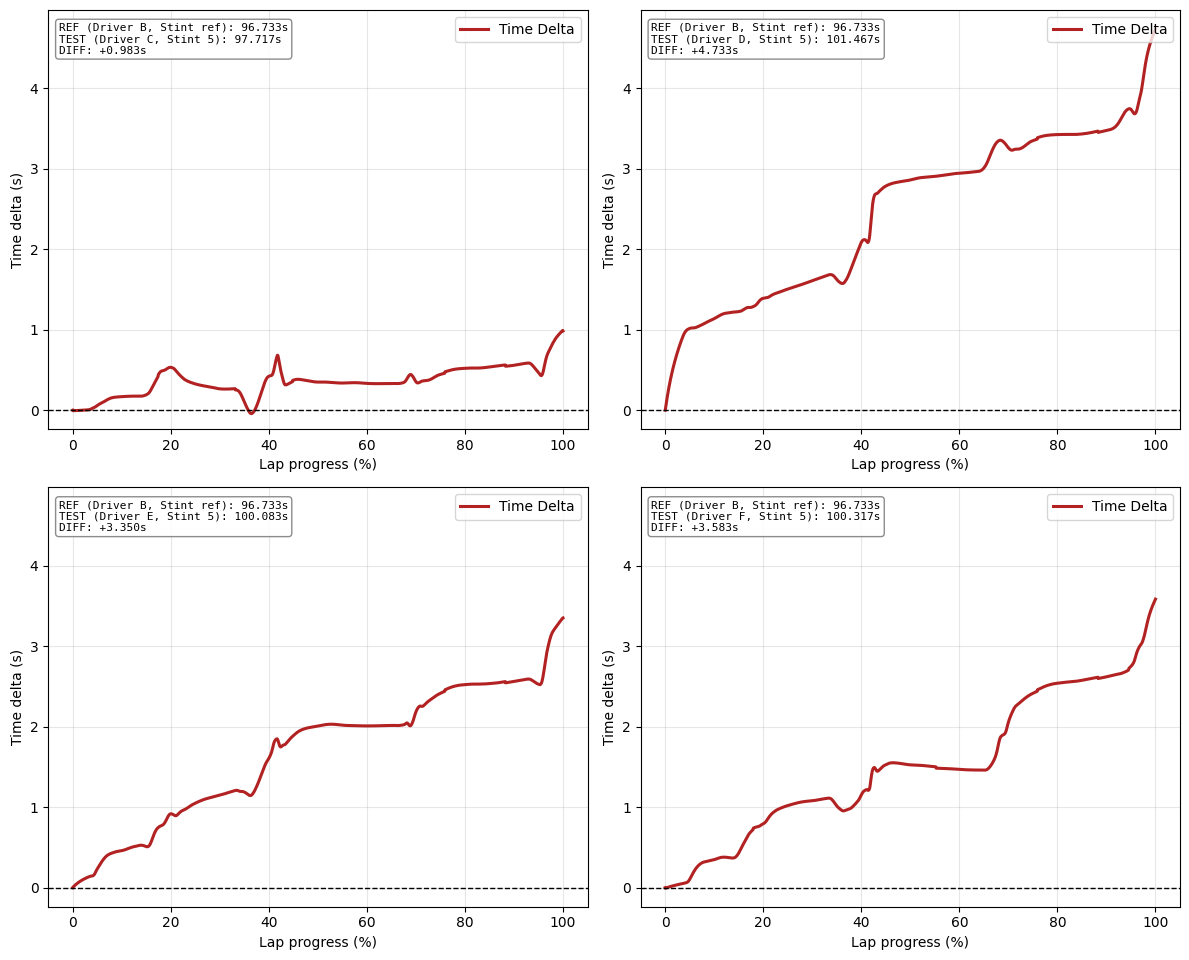

    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35(Tomaz-stint_ref).ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-06 17-13-21(morsinaldo-stint5).ibt … OK (69,741 samples, laps 0–14)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35(Tomaz-stint_ref).ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-06 22-01-39(Thallys-stint5).ibt … OK (42,675 samples, laps 0–9)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35(Tomaz-stint_ref).ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-11 17-38-46(igor-stint5).ibt … OK (16,934 samples, laps 0–4)
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35(Tomaz-stint_ref).ibt … OK (60,130 samples, laps 0–12)
    [1/1] Loading toyotagr86_summit summit raceway 2026-07-07 14-21-27(hilton-stint5).ibt … OK (16,655 samples, laps 0–4)
Saved: C

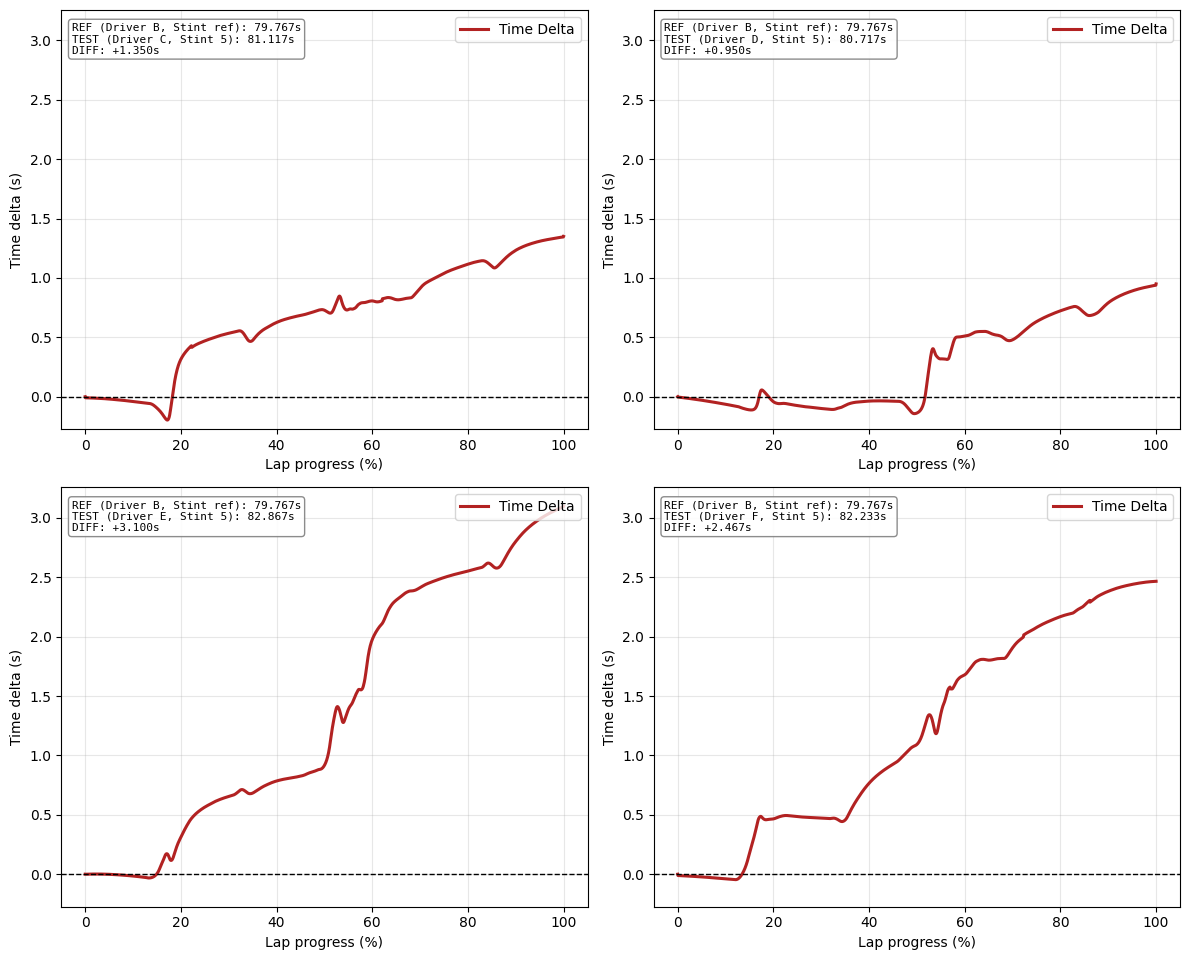

In [17]:
for track_id in DATASETS.keys():
    plot_amateur_grid(track_id, master_laps, amateurs=AMATEURS, 
                      target_stint_ref="stint_ref", target_stint_test="stint_5")

## 5. Evolução do tempo de volta ao longo dos stints

Objetivo: verificar efeito de prática/familiarização — relevante para os revisores que questionam se a melhora pós-coaching não é simplesmente aprendizado por repetição (Revisor 1 e 2, item de grupo de controle).

In [9]:
import re

def stint_sort_key(stint_name: str):
    """Extrai o número do stint para ordenação (ex.: 'stint_3' -> 3). Não numéricos vão pro início (warmup)."""
    m = re.search(r"(\d+)", stint_name)
    return int(m.group(1)) if m else -1


def build_stint_progression_table(master_laps: pd.DataFrame, exclude_warmup=True):
    df = master_laps[master_laps["Valid"]].copy()
    if exclude_warmup:
        df = df[~df["Stint"].str.contains("warmup|aquecimento|stint_ref", case=False, na=False)]

    df["StintOrder"] = df["Stint"].apply(stint_sort_key)

    agg = (
        df.groupby(["Track", "Driver", "Role", "Stint", "StintOrder"])["LapTime_s"]
        .agg(best="min", mean="mean", n="count")
        .reset_index()
        .sort_values(["Track", "Driver", "StintOrder"])
    )
    return agg




def plot_stint_progression(progression_df: pd.DataFrame, track_id: str, metric="best"):
    df_track = progression_df[progression_df["Track"] == track_id]
    
    drivers = sorted(df_track["Driver"].unique())
    cmap = plt.get_cmap("tab10")   # até 20 cores diferentes

    DRIVER_COLORS = {
        d: cmap(i % cmap.N)
        for i, d in enumerate(drivers)
    }

    fig, ax = plt.subplots(figsize=(11, 6))
    
    for driver, g in df_track.groupby("Driver"):
        role = ROLE_MAP.get(driver, "Desconhecido")
        color = DRIVER_COLORS[driver]
        is_new = "novo" in role.lower()

        ax.plot(
            g["StintOrder"],
            g[metric],
            marker="o",
            label=role,               # ou f"{driver} ({role})"
            color=color,
            linewidth=2,
            alpha=0.7 if is_new else 1.0,
            linestyle="--" if is_new else "-"
        )
        
    track_name = TRACK_CONFIGS[track_id]["track_name"]
    ax.set_xlabel("Stint")
    ax.set_ylabel(f"Lap time {metric} (s)")
    #ax.set_title(f"Laptime per Stint — {track_name}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    fname = f"stint_progression_{track_id}_{metric}.pdf"
    plt.savefig(OUT_DIR / fname, dpi=300, bbox_inches="tight")
    print(f"Salvo: {OUT_DIR / fname}")
    plt.show()


Salvo: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\stint_progression_charlotte_roval_2025_best.pdf


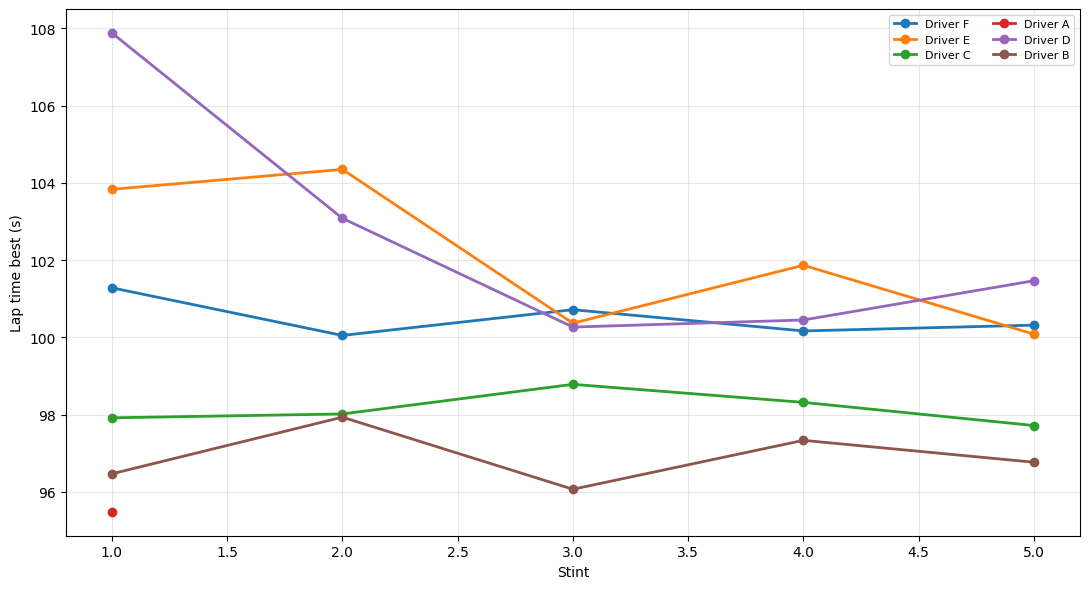

Salvo: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\unified_analysis\stint_progression_summit_point_best.pdf


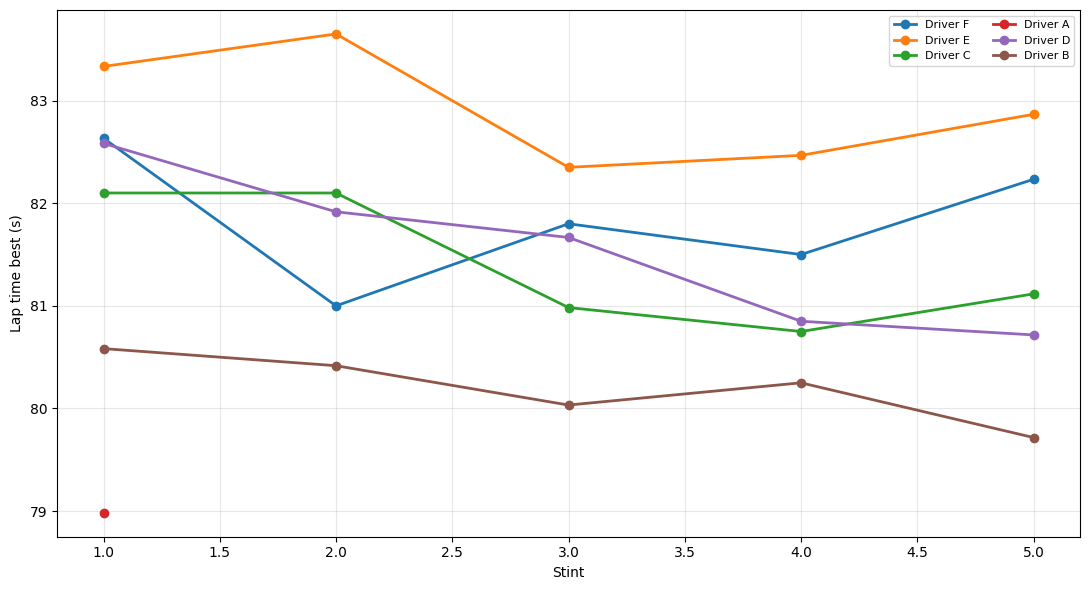

,Track,Driver,Role,Stint,StintOrder,best,mean,n
0,charlotte_roval_2025,Hilton,Driver F,stint_1,1,101.283333,105.104167,4
1,charlotte_roval_2025,Hilton,Driver F,stint_2,2,100.050000,101.337500,4
2,charlotte_roval_2025,Hilton,Driver F,stint_3,3,100.716667,101.425000,2
3,charlotte_roval_2025,Hilton,Driver F,stint_4,4,100.166667,102.997222,6
4,charlotte_roval_2025,Hilton,Driver F,stint_5,5,100.316667,101.416667,4
5,charlotte_roval_2025,Igor,Driver E,stint_1,1,103.833333,111.258333,6
6,charlotte_roval_2025,Igor,Driver E,stint_2,2,104.350000,111.207143,7
7,charlotte_roval_2025,Igor,Driver E,stint_3,3,100.366667,101.216667,2
8,charlotte_roval_2025,Igor,Driver E,stint_4,4,101.866667,104.113333,5
9,charlotte_roval_2025,Igor,Driver E,stint_5,5,100.083333,103.887500,4


In [10]:
progression_df = build_stint_progression_table(master_laps)
for track_id in DATASETS.keys():
    plot_stint_progression(progression_df, track_id, metric="best")

progression_df.head(15)


## 6. Tabela-resumo para atualizar a Tabela 5 do artigo

Colunas: pista, piloto, papel, melhor volta, volta média (válidas), nº de voltas válidas, delta vs Intermediário, delta vs Experiente.

In [11]:
# =====================================================================
# 6b. Baseline (Stint 1) + Progressão (Stint 2→4) + Resultado Final (Stint 5)
#
# Convenção de referência (CORRIGIDA — hierarquia de comparação):
#   • Tomaz (Intermediate) → comparado ao stint_1 do Rodrigo (Expert)
#       Delta = Tomaz − Rodrigo   (positivo = Tomaz mais lento que o Expert)
#   • Amadores             → comparados ao stint_ref fixo do Tomaz
#       Delta = Amador − Tomaz    (positivo = amador mais lento que o Intermediate)
#   • Rodrigo (Expert)     → topo da hierarquia; não tem referência (Delta = NaN)
#
# A coluna "Reference" em cada tabela documenta qual baseline foi usado
# em cada linha, evitando ambiguidade na Tabela do artigo.
# =====================================================================

def _best_valid_lap(master_laps: pd.DataFrame, track_id: str, driver: str, stint: str):
    """Melhor volta válida de (track, driver, stint); np.nan se não existir."""
    g = master_laps[
        (master_laps["Track"] == track_id)
        & (master_laps["Driver"] == driver)
        & (master_laps["Stint"] == stint)
        & (master_laps["Valid"])
    ]
    return g["LapTime_s"].min() if not g.empty else np.nan


def get_reference_time(master_laps: pd.DataFrame, track_id: str, driver: str):
    """
    Referência específica por piloto (retorna (ref_time, ref_label)):
      • Tomaz    → best lap do stint_1 do Rodrigo (todos os stints do Tomaz vs Expert)
      • Amadores → best lap do stint_ref do Tomaz
      • Rodrigo  → np.nan (é a referência-teto; ninguém acima dele)
    """
    if driver == REFERENCE_EXPERT:
        return np.nan, "—"

    if driver == REFERENCE_INTERMEDIATE:
        ref = _best_valid_lap(master_laps, track_id, REFERENCE_EXPERT, "stint_1")
        if np.isnan(ref):
            print(f"AVISO: sem stint_1 válido do {REFERENCE_EXPERT} em {track_id}")
        return ref, f"{REFERENCE_EXPERT} (stint_1)"

    # Amadores
    ref = _best_valid_lap(master_laps, track_id, REFERENCE_INTERMEDIATE, "stint_ref")
    if np.isnan(ref):
        print(f"AVISO: sem stint_ref válido do {REFERENCE_INTERMEDIATE} em {track_id}")
    return ref, f"{REFERENCE_INTERMEDIATE} (stint_ref)"


# ---------------------------------------------------------------------
# Tabela 1 — Baseline: melhor volta válida no stint_1, todos os pilotos
# ---------------------------------------------------------------------
def build_baseline_table(master_laps: pd.DataFrame, baseline_stint: str = "stint_1"):
    rows = []
    for track_id in DATASETS.keys():
        valid = master_laps[
            (master_laps["Track"] == track_id)
            & (master_laps["Valid"])
            & (master_laps["Stint"] == baseline_stint)
        ]
        if valid.empty:
            continue

        for driver, g in valid.groupby("Driver"):
            best = g["LapTime_s"].min()
            ref_time, ref_label = get_reference_time(master_laps, track_id, driver)
            rows.append({
                "Track": track_id,
                "Driver": driver,
                "Role": ROLE_MAP.get(driver, "Desconhecido"),
                "Baseline_Stint": baseline_stint,
                "BaselineLap_s": best,
                "N_ValidLaps_Baseline": int(len(g)),
                "Delta_vs_Reference_s": np.round(best - ref_time, 3) if pd.notna(ref_time) else np.nan,
                "Reference": ref_label,
            })
    return pd.DataFrame(rows).sort_values(["Track", "BaselineLap_s"])


# ---------------------------------------------------------------------
# Tabela 2 — Progressão: best lap por stint, Stint 2 → 4
#   Rodrigo sai naturalmente (só tem stint_1 por desenho do estudo).
# ---------------------------------------------------------------------
def build_progression_summary(progression_df: pd.DataFrame, stint_range=(2, 4)):
    """Evolução best-lap por stint. NaN é preservado apenas quando o stint
    genuinamente não foi rodado — não silenciamos com fillna."""
    df = progression_df[
        (progression_df["StintOrder"] >= stint_range[0])
        & (progression_df["StintOrder"] <= stint_range[1])
    ].copy()

    pivot = (
        df.pivot_table(index=["Track", "Driver", "Role"],
                       columns="StintOrder", values="best")
        .reset_index()
    )
    pivot.columns = [f"Stint_{c}_best_s" if isinstance(c, int) else c for c in pivot.columns]

    stint_cols = [c for c in pivot.columns if c.startswith("Stint_")]
    first_col, last_col = stint_cols[0], stint_cols[-1]

    # Improvement só quando AMBOS os extremos existem (evita NaN - NaN silencioso)
    both_present = pivot[first_col].notna() & pivot[last_col].notna()
    pivot["Improvement_s"] = np.round(
        np.where(both_present, pivot[first_col] - pivot[last_col], np.nan), 3)
    pivot["Improvement_pct"] = np.round(
        np.where(both_present, (pivot["Improvement_s"] / pivot[first_col]) * 100, np.nan), 3)

    pivot["Coverage_Note"] = np.where(
        pivot[stint_cols].isna().any(axis=1),
        "Incomplete (see datasets.py: stint pending or N/A)",
        "Complete"
    )
    return pivot.sort_values(["Track", last_col])


# ---------------------------------------------------------------------
# Tabela 3 — Resultado final: melhor volta válida no stint_5,
#   cada piloto contra a SUA referência (Tomaz→Rodrigo; Amadores→stint_ref)
# ---------------------------------------------------------------------
def build_final_result_table(master_laps: pd.DataFrame, final_stint: str = "stint_5"):
    rows = []
    for track_id in DATASETS.keys():
        valid = master_laps[
            (master_laps["Track"] == track_id)
            & (master_laps["Valid"])
            & (master_laps["Stint"] == final_stint)
        ]
        for driver, g in valid.groupby("Driver"):
            best = g["LapTime_s"].min()
            ref_time, ref_label = get_reference_time(master_laps, track_id, driver)
            rows.append({
                "Track": track_id,
                "Driver": driver,
                "Role": ROLE_MAP.get(driver, "Desconhecido"),
                "Final_Stint": final_stint,
                "FinalLap_s": best,
                "N_ValidLaps_Final": int(len(g)),
                "Delta_vs_Reference_s": np.round(best - ref_time, 3) if pd.notna(ref_time) else np.nan,
                "Reference": ref_label,
            })

        # Linha explícita para quem não rodou o stint final
        # (ex.: Tomaz em Charlotte só tem stints 1-4; Rodrigo só tem stint_1)
        missing = set(DATASETS[track_id]["sessions"].keys()) - set(valid["Driver"].unique())
        for driver in missing:
            _, ref_label = get_reference_time(master_laps, track_id, driver)
            rows.append({
                "Track": track_id, "Driver": driver,
                "Role": ROLE_MAP.get(driver, "Desconhecido"),
                "Final_Stint": final_stint, "FinalLap_s": np.nan,
                "N_ValidLaps_Final": 0, "Delta_vs_Reference_s": np.nan,
                "Reference": ref_label,
            })

    return pd.DataFrame(rows).sort_values(["Track", "FinalLap_s"])


baseline_table = build_baseline_table(master_laps, baseline_stint="stint_1")
progression_summary = build_progression_summary(progression_df, stint_range=(2, 4))
final_result_table = build_final_result_table(master_laps, final_stint="stint_5")

print("=== TABELA 1: BASELINE (Stint 1, referência por piloto) ===")
display(baseline_table)
print("\n=== TABELA 2: PROGRESSÃO (Stint 2 → 4) ===")
display(progression_summary)
print("\n=== TABELA 3: RESULTADO FINAL (Stint 5) ===")
display(final_result_table)

=== TABELA 1: BASELINE (Stint 1, referência por piloto) ===


,Track,Driver,Role,Baseline_Stint,BaselineLap_s,N_ValidLaps_Baseline,Delta_vs_Reference_s,Reference
3,charlotte_roval_2025,Rodrigo,Driver A,stint_1,95.483333,36,NaN,—
5,charlotte_roval_2025,Tomaz,Driver B,stint_1,96.466667,2,0.983,Rodrigo (stint_1)
2,charlotte_roval_2025,Morsinaldo,Driver C,stint_1,97.916667,2,1.183,Tomaz (stint_ref)
0,charlotte_roval_2025,Hilton,Driver F,stint_1,101.283333,4,4.550,Tomaz (stint_ref)
1,charlotte_roval_2025,Igor,Driver E,stint_1,103.833333,6,7.100,Tomaz (stint_ref)
4,charlotte_roval_2025,Thallys,Driver D,stint_1,107.883333,3,11.150,Tomaz (stint_ref)
9,summit_point,Rodrigo,Driver A,stint_1,78.983333,13,NaN,—
11,summit_point,Tomaz,Driver B,stint_1,80.583333,5,1.600,Rodrigo (stint_1)
8,summit_point,Morsinaldo,Driver C,stint_1,82.100000,4,2.333,Tomaz (stint_ref)
10,summit_point,Thallys,Driver D,stint_1,82.583333,5,2.817,Tomaz (stint_ref)



=== TABELA 2: PROGRESSÃO (Stint 2 → 4) ===


,Track,Driver,Role,Stint_2_best_s,Stint_3_best_s,Stint_4_best_s,Improvement_s,Improvement_pct,Coverage_Note
4,charlotte_roval_2025,Tomaz,Driver B,97.933333,96.066667,97.333333,0.600,0.613,Complete
2,charlotte_roval_2025,Morsinaldo,Driver C,98.016667,98.783333,98.316667,-0.300,-0.306,Complete
0,charlotte_roval_2025,Hilton,Driver F,100.050000,100.716667,100.166667,-0.117,-0.117,Complete
3,charlotte_roval_2025,Thallys,Driver D,103.083333,100.266667,100.450000,2.633,2.554,Complete
1,charlotte_roval_2025,Igor,Driver E,104.350000,100.366667,101.866667,2.483,2.379,Complete
9,summit_point,Tomaz,Driver B,80.416667,80.033333,80.250000,0.167,0.208,Complete
7,summit_point,Morsinaldo,Driver C,82.100000,80.983333,80.750000,1.350,1.644,Complete
8,summit_point,Thallys,Driver D,81.916667,81.666667,80.850000,1.067,1.303,Complete
5,summit_point,Hilton,Driver F,81.000000,81.800000,81.500000,-0.500,-0.617,Complete
6,summit_point,Igor,Driver E,83.650000,82.350000,82.466667,1.183,1.414,Complete



=== TABELA 3: RESULTADO FINAL (Stint 5) ===


,Track,Driver,Role,Final_Stint,FinalLap_s,N_ValidLaps_Final,Delta_vs_Reference_s,Reference
4,charlotte_roval_2025,Tomaz,Driver B,stint_5,96.766667,2,1.283,Rodrigo (stint_1)
2,charlotte_roval_2025,Morsinaldo,Driver C,stint_5,97.716667,2,0.983,Tomaz (stint_ref)
1,charlotte_roval_2025,Igor,Driver E,stint_5,100.083333,4,3.350,Tomaz (stint_ref)
0,charlotte_roval_2025,Hilton,Driver F,stint_5,100.316667,4,3.583,Tomaz (stint_ref)
3,charlotte_roval_2025,Thallys,Driver D,stint_5,101.466667,5,4.733,Tomaz (stint_ref)
5,charlotte_roval_2025,Rodrigo,Driver A,stint_5,NaN,0,NaN,—
10,summit_point,Tomaz,Driver B,stint_5,79.716667,4,0.733,Rodrigo (stint_1)
9,summit_point,Thallys,Driver D,stint_5,80.716667,8,0.950,Tomaz (stint_ref)
8,summit_point,Morsinaldo,Driver C,stint_5,81.116667,11,1.350,Tomaz (stint_ref)
6,summit_point,Hilton,Driver F,stint_5,82.233333,3,2.467,Tomaz (stint_ref)


In [12]:
def build_table5_summary(master_laps: pd.DataFrame):
    rows = []
    for track_id in DATASETS.keys():
        valid = master_laps[(master_laps["Track"] == track_id) & (master_laps["Valid"])]
        if valid.empty:
            continue

        ref_best = valid[valid["Driver"] == REFERENCE_INTERMEDIATE]["LapTime_s"].min()
        exp_best = valid[valid["Driver"] == REFERENCE_EXPERT]["LapTime_s"].min()

        for driver, g in valid.groupby("Driver"):
            best = g["LapTime_s"].min()
            rows.append({
                "Track": track_id,
                "Driver": driver,
                "Role": ROLE_MAP.get(driver, "Desconhecido"),
                "BestLap_s": best,
                "MeanLap_s": g["LapTime_s"].mean(),
                "N_ValidLaps": int(len(g)),
                "Best_Stint": g.loc[g["LapTime_s"].idxmin(), "Stint"],
                "Delta_vs_Intermediate_s": best - ref_best if driver != REFERENCE_INTERMEDIATE else 0.0,
                "Delta_vs_Expert_s": best - exp_best if driver != REFERENCE_EXPERT else 0.0,
            })

    return pd.DataFrame(rows).sort_values(["Track", "BestLap_s"])


table5_df = build_table5_summary(master_laps)
table5_df


,Track,Driver,Role,BestLap_s,MeanLap_s,N_ValidLaps,Best_Stint,Delta_vs_Intermediate_s,Delta_vs_Expert_s
3,charlotte_roval_2025,Rodrigo,Driver A,95.483333,97.566667,36,stint_1,-0.583333,0.000000
5,charlotte_roval_2025,Tomaz,Driver B,96.066667,98.851316,38,stint_3,0.000000,0.583333
2,charlotte_roval_2025,Morsinaldo,Driver C,97.716667,102.022222,18,stint_5,1.650000,2.233333
0,charlotte_roval_2025,Hilton,Driver F,100.050000,103.190667,25,stint_2,3.983333,4.566667
1,charlotte_roval_2025,Igor,Driver E,100.083333,107.700000,25,stint_5,4.016667,4.600000
4,charlotte_roval_2025,Thallys,Driver D,100.266667,106.946154,26,stint_3,4.200000,4.783333
9,summit_point,Rodrigo,Driver A,78.983333,79.476923,13,stint_1,-0.733333,0.000000
11,summit_point,Tomaz,Driver B,79.716667,81.512121,33,stint_5,0.000000,0.733333
10,summit_point,Thallys,Driver D,80.716667,84.665054,31,stint_5,1.000000,1.733333
8,summit_point,Morsinaldo,Driver C,80.750000,83.267949,26,stint_4,1.033333,1.766667


### Observações para a atualização manual da Tabela 5

- Confira `ROLE_MAP` no topo do notebook antes de usar estes números no artigo.
- `Delta_vs_Intermediate_s`/`Delta_vs_Expert_s` usam a **melhor volta válida geral** por piloto/pista (não um stint específico); ajuste `build_table5_summary` se a Tabela 5 exigir um stint fixo (ex.: apenas pós-coaching).
- `stint_progression_table.csv` já está pronto para um teste de tendência (ex.: regressão linear do tempo de volta vs. número do stint) na resposta ao Revisor 1/2 sobre efeito de prática.

## 7. Prática/familiarização vs. efeito do coaching — baseline de variação run-to-run

Resposta aos Revisores 1 e 2 (melhora pode ser prática) e Revisor 3 (falta de baseline
de variação run-to-run). Usa Igor (controle, nunca recebeu feedback) e os stints de Tomaz
pós-feedback (2→3, 3→4, 4→5) para construir um pool de deltas de lap time "naturais"
(prática + ruído run-to-run, sem evento de coaching novo). Cada delta pós-feedback
(stint_1 → stint_2 de Tomaz, Thallys, Hilton, Morsinaldo) é comparado contra esse pool.

In [13]:
FEEDBACK_EVENT = {
    "Tomaz":      ("stint_1", "stint_2"),  # feedback baseado no stint_1 do Rodrigo
    "Thallys":    ("stint_1", "stint_2"),  # feedback baseado no stint_1 do Tomaz
    "Hilton":     ("stint_1", "stint_2"),
    "Morsinaldo": ("stint_1", "stint_2"),
}

def build_stint_delta_table(progression_df, feedback_event=FEEDBACK_EVENT, metric="best"):
    """Deltas consecutivos de lap time por (Track, Driver): 'feedback_event' (transição
    com coaching) vs. 'natural' (sem coaching novo entre os dois stints)."""
    rows = []
    for (track, driver), g in progression_df.groupby(["Track", "Driver"]):
        g = g.sort_values("StintOrder")
        stints, vals = g["Stint"].tolist(), g[metric].tolist()
        for i in range(1, len(stints)):
            is_fb = (driver in feedback_event
                      and stints[i - 1] == feedback_event[driver][0]
                      and stints[i] == feedback_event[driver][1])
            rows.append({
                "Track": track, "Driver": driver,
                "Stint_from": stints[i - 1], "Stint_to": stints[i],
                "Delta_s": vals[i] - vals[i - 1],
                "Label": "feedback_event" if is_fb else "natural",
            })
    return pd.DataFrame(rows)

delta_df = build_stint_delta_table(progression_df)

In [14]:
from scipy.stats import permutation_test

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_sd = np.sqrt(((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    return (x.mean() - y.mean()) / pooled_sd

igor_natural = delta_df.loc[
    (delta_df.Driver == "Igor") & (delta_df.Label == "natural"), "Delta_s"
].values

amateur_treatment = delta_df.loc[
    delta_df.Driver.isin(["Thallys", "Hilton", "Morsinaldo"]) & (delta_df.Label == "feedback_event"),
    "Delta_s"
].values

res_igor = permutation_test(
    (amateur_treatment, igor_natural),
    lambda x, y: x.mean() - y.mean(),
    alternative="less", n_resamples=100_000, random_state=42
)
d_igor = cohens_d(amateur_treatment, igor_natural)

print(f"Igor (controle), n={len(igor_natural)}: média={igor_natural.mean():+.3f}s | SD={igor_natural.std(ddof=1):.3f}s")
print(f"Amadores c/ feedback, n={len(amateur_treatment)}: média={amateur_treatment.mean():+.3f}s | SD={amateur_treatment.std(ddof=1):.3f}s")
print(f"p (unilateral, Monte Carlo) = {res_igor.pvalue:.5f}  |  Cohen's d = {d_igor:.3f}")

Igor (controle), n=8: média=-0.527s | SD=1.745s
Amadores c/ feedback, n=6: média=-1.372s | SD=1.810s
p (unilateral, Monte Carlo) = 0.19081  |  Cohen's d = -0.477


In [15]:
def intra_stint_lap_sd(track_id, driver, stint, master_laps):
    laps = master_laps[
        (master_laps.Track == track_id) & (master_laps.Driver == driver)
        & (master_laps.Stint == stint) & (master_laps.Valid)
    ]["LapTime_s"]
    return laps.std(ddof=1), len(laps)

tomaz_deltas = delta_df.loc[
    (delta_df.Driver == "Tomaz") & (delta_df.Label == "feedback_event")
]

rows = []
for _, row in tomaz_deltas.iterrows():
    sd_rodrigo, n_laps = intra_stint_lap_sd(row.Track, "Rodrigo", "stint_1", master_laps)
    rows.append({
        "Track": row.Track, "Delta_Tomaz_s": row.Delta_s,
        "SD_intra_stint_Rodrigo_s": sd_rodrigo, "N_laps_Rodrigo": n_laps,
        "Delta_within_1SD": abs(row.Delta_s) < sd_rodrigo,
    })

tomaz_summary = pd.DataFrame(rows)
print(tomaz_summary.to_string(index=False))

               Track  Delta_Tomaz_s  SD_intra_stint_Rodrigo_s  N_laps_Rodrigo  Delta_within_1SD
charlotte_roval_2025       1.466667                  2.281447              36              True
        summit_point      -0.166667                  0.558956              13              True


In [16]:
summary_rows = [
    {"Comparação": "Amadores (feedback) vs. Igor (controle)",
     "N_tratamento": len(amateur_treatment), "N_controle": len(igor_natural),
     "Média_delta_tratamento_s": amateur_treatment.mean(),
     "Média_delta_controle_s": igor_natural.mean(),
     "Cohen_d": d_igor, "p_valor": res_igor.pvalue, "Método": "Permutação Monte Carlo (100k)"},
]
for _, r in tomaz_summary.iterrows():
    summary_rows.append({
        "Comparação": f"Tomaz (feedback) vs. ruído intra-stint Rodrigo — {r.Track}",
        "N_tratamento": 1, "N_controle": r.N_laps_Rodrigo,
        "Média_delta_tratamento_s": r.Delta_Tomaz_s,
        "Média_delta_controle_s": np.nan,
        "Cohen_d": np.nan, "p_valor": np.nan,
        "Método": f"Descritivo — |delta| {'<' if r.Delta_within_1SD else '>='} 1 SD intra-stint ({r.SD_intra_stint_Rodrigo_s:.3f}s)",
    })

table_run_to_run = pd.DataFrame(summary_rows)
table_run_to_run.to_csv(OUT_DIR / "run_to_run_baseline_summary.csv", index=False)
table_run_to_run

,Comparação,N_tratamento,N_controle,Média_delta_tratamento_s,Média_delta_controle_s,Cohen_d,p_valor,Método
0,Amadores (feedback) vs. Igor (controle),6,8,-1.372222,-0.527083,-0.476871,0.190809,Permutação Monte Carlo (100k)
1,Tomaz (feedback) vs. ruído intra-stint Rodrigo...,1,36,1.466667,NaN,NaN,NaN,Descritivo — |delta| < 1 SD intra-stint (2.281s)
2,Tomaz (feedback) vs. ruído intra-stint Rodrigo...,1,13,-0.166667,NaN,NaN,NaN,Descritivo — |delta| < 1 SD intra-stint (0.559s)


**Controle de prática/familiarização e variação run-to-run.** Para o par Amador-tratado/Amador-controle, o delta de lap time observado após o feedback (M=−1.372s, SD=1.810s, n=6) foi comparado contra o baseline de variação natural (prática + ruído run-to-run) do piloto controle Igor (M=−0.527s, SD=1.745s, n=8), via teste de permutação (Monte Carlo, 100.000 reamostragens): d de Cohen = −0.477, p = 0.191 (unilateral). 

O efeito está na direção esperada e é de magnitude moderada, mas não atinge significância convencional dado N — resultado reportado como evidência exploratória, não confirmatória. Para o par Experiente/Intermediário, a ausência de repetições do piloto de referência (Rodrigo, 1 stint) impede um baseline stint-a-stint; como proxy complementar, a variabilidade volta-a-volta intra-stint do Rodrigo (SD=2.281s em Charlotte, SD=0.559s em Summit Point) excede em magnitude o delta observado em Tomaz (+0.317s e −0.167s, respectivamente), indicando que a mudança em Tomaz é indistinguível do ruído natural de desempenho.